<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

# Python for Finance

**Analyze Big Financial Data**

O'Reilly (2014)

Yves Hilpisch

<img style="border:0px solid grey;" src="http://hilpisch.com/python_for_finance.png" alt="Python for Finance" width="30%" align="left" border="0">

**Buy the book ** |
<a href='http://shop.oreilly.com/product/0636920032441.do' target='_blank'>O'Reilly</a> |
<a href='http://www.amazon.com/Yves-Hilpisch/e/B00JCYHHJM' target='_blank'>Amazon</a>

**All book codes & IPYNBs** |
<a href="http://oreilly.quant-platform.com">http://oreilly.quant-platform.com</a>

**The Python Quants GmbH** | <a href='http://tpq.io' target='_blank'>http://tpq.io</a>

**Contact us** | <a href='mailto:pff@tpq.io'>pff@tpq.io</a>

# Financial Time Series

In [1]:
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import matplotlib as mpl
mpl.rcParams['font.family'] = 'serif'

## pandas Basics

In [2]:
import numpy as np
import pandas as pd

### First Steps with DataFrame Class

In [3]:
df = pd.DataFrame([10, 20, 30, 40], columns=['numbers'],
                  index=['a', 'b', 'c', 'd'])
df

,numbers
a,10
b,20
c,30
d,40


In [4]:
df.index  # the index values

Index(['a', 'b', 'c', 'd'], dtype='object')

In [5]:
df.columns  # the column names

Index(['numbers'], dtype='object')

In [6]:
df.loc['c']  # selection via index

numbers    30
Name: c, dtype: int64

In [7]:
df.loc[['a', 'd']]  # selection of multiple indices

,numbers
a,10
d,40


In [8]:
df.loc[df.index[1:3]]  # selection via Index object

,numbers
b,20
c,30


In [9]:
df.sum()  # sum per column

numbers    100
dtype: int64

In [10]:
df.apply(lambda x: x ** 2)  # square of every element

,numbers
a,100
b,400
c,900
d,1600


In [11]:
df ** 2  # again square, this time NumPy-like

,numbers
a,100
b,400
c,900
d,1600


In [12]:
df['floats'] = (1.5, 2.5, 3.5, 4.5)
  # new column is generated
df

,numbers,floats
a,10,1.5
b,20,2.5
c,30,3.5
d,40,4.5


In [13]:
df['floats']  # selection of column

a    1.5
b    2.5
c    3.5
d    4.5
Name: floats, dtype: float64

In [14]:
df['names'] = pd.DataFrame(['Yves', 'Guido', 'Felix', 'Francesc'],
                           index=['d', 'a', 'b', 'c'])
df

,numbers,floats,names
a,10,1.5,Guido
b,20,2.5,Felix
c,30,3.5,Francesc
d,40,4.5,Yves


In [15]:
pd.DataFrame([{'numbers': 100, 'floats': 5.75, 'names': 'Henry'}])

,numbers,floats,names
0,100,5.75,Henry


In [16]:
# 使用 pd.concat() 替代已弃用的 append() 方法
pd.concat([df, pd.DataFrame([{'numbers': 100, 'floats': 5.75, 'names': 'Henry'}])], 
          ignore_index=True)
  # temporary object; df not changed

,numbers,floats,names
0,10,1.50,Guido
1,20,2.50,Felix
2,30,3.50,Francesc
3,40,4.50,Yves
4,100,5.75,Henry


In [17]:
# 使用 pd.concat() 替代已弃用的 append() 方法
df = pd.concat([df, pd.DataFrame({'numbers': 100, 'floats': 5.75,
                                 'names': 'Henry'}, index=['z'])], 
               ignore_index=False)
df

,numbers,floats,names
a,10,1.50,Guido
b,20,2.50,Felix
c,30,3.50,Francesc
d,40,4.50,Yves
z,100,5.75,Henry


In [18]:
pd.DataFrame([1, 4, 9, 16, 25],
            index=['a', 'b', 'c', 'd', 'y'],
            columns=['squares',])

,squares
a,1
b,4
c,9
d,16
y,25


In [19]:
df

,numbers,floats,names
a,10,1.50,Guido
b,20,2.50,Felix
c,30,3.50,Francesc
d,40,4.50,Yves
z,100,5.75,Henry


In [20]:
df.join(pd.DataFrame([1, 4, 9, 16, 25],
            index=['a', 'b', 'c', 'd', 'y'],
            columns=['squares',]))
  # temporary object

,numbers,floats,names,squares
a,10,1.50,Guido,1.0
b,20,2.50,Felix,4.0
c,30,3.50,Francesc,9.0
d,40,4.50,Yves,16.0
z,100,5.75,Henry,NaN


In [21]:
df = df.join(pd.DataFrame([1, 4, 9, 16, 25],
                    index=['a', 'b', 'c', 'd', 'y'],
                    columns=['squares',]),
                    how='outer')
df

,numbers,floats,names,squares
a,10.0,1.50,Guido,1.0
b,20.0,2.50,Felix,4.0
c,30.0,3.50,Francesc,9.0
d,40.0,4.50,Yves,16.0
y,NaN,NaN,NaN,25.0
z,100.0,5.75,Henry,NaN


In [22]:
df[['numbers', 'squares']].mean()
  # column-wise mean

numbers    40.0
squares    11.0
dtype: float64

In [23]:
df[['numbers', 'squares']].std()
  # column-wise standard deviation

numbers    35.355339
squares     9.669540
dtype: float64

### Second Steps with DataFrame Class

In [24]:
a = np.random.standard_normal((9, 4))
a.round(6)

array([[ 0.423495, -0.202296, -0.813504,  1.678197],
       [ 1.367746,  1.587229,  0.533816,  0.597964],
       [-1.520809,  0.400532,  1.725188, -0.718432],
       [-1.977869,  1.169865, -2.179774,  0.256576],
       [ 1.964831,  1.061122, -0.669239,  0.066376],
       [ 1.174812, -0.122311,  0.405334, -0.313865],
       [ 0.28585 ,  0.61577 , -1.108309,  1.900194],
       [ 0.077286, -0.589497,  0.547255,  0.725146],
       [ 0.520565, -0.567541, -0.979461, -0.283658]])

In [25]:
df = pd.DataFrame(a)
df

,0,1,2,3
0,0.423495,-0.202296,-0.813504,1.678197
1,1.367746,1.587229,0.533816,0.597964
2,-1.520809,0.400532,1.725188,-0.718432
3,-1.977869,1.169865,-2.179774,0.256576
4,1.964831,1.061122,-0.669239,0.066376
5,1.174812,-0.122311,0.405334,-0.313865
6,0.285850,0.615770,-1.108309,1.900194
7,0.077286,-0.589497,0.547255,0.725146
8,0.520565,-0.567541,-0.979461,-0.283658


In [26]:
df.columns = ['No1', 'No2', 'No3', 'No4']
df

,No1,No2,No3,No4
0,0.423495,-0.202296,-0.813504,1.678197
1,1.367746,1.587229,0.533816,0.597964
2,-1.520809,0.400532,1.725188,-0.718432
3,-1.977869,1.169865,-2.179774,0.256576
4,1.964831,1.061122,-0.669239,0.066376
5,1.174812,-0.122311,0.405334,-0.313865
6,0.285850,0.615770,-1.108309,1.900194
7,0.077286,-0.589497,0.547255,0.725146
8,0.520565,-0.567541,-0.979461,-0.283658


In [27]:
df['No2'].iloc[3]  # value in column No2 at index position 3

1.1698647236797353

In [30]:
dates = pd.date_range('2015-1-1', periods=9)
dates

DatetimeIndex(['2015-01-01', '2015-01-02', '2015-01-03', '2015-01-04',
               '2015-01-05', '2015-01-06', '2015-01-07', '2015-01-08',
               '2015-01-09'],
              dtype='datetime64[ns]', freq='D')

In [31]:
df.index = dates
df

,No1,No2,No3,No4
2015-01-01,0.423495,-0.202296,-0.813504,1.678197
2015-01-02,1.367746,1.587229,0.533816,0.597964
2015-01-03,-1.520809,0.400532,1.725188,-0.718432
2015-01-04,-1.977869,1.169865,-2.179774,0.256576
2015-01-05,1.964831,1.061122,-0.669239,0.066376
2015-01-06,1.174812,-0.122311,0.405334,-0.313865
2015-01-07,0.285850,0.615770,-1.108309,1.900194
2015-01-08,0.077286,-0.589497,0.547255,0.725146
2015-01-09,0.520565,-0.567541,-0.979461,-0.283658


In [32]:
np.array(df).round(6)

array([[ 0.423495, -0.202296, -0.813504,  1.678197],
       [ 1.367746,  1.587229,  0.533816,  0.597964],
       [-1.520809,  0.400532,  1.725188, -0.718432],
       [-1.977869,  1.169865, -2.179774,  0.256576],
       [ 1.964831,  1.061122, -0.669239,  0.066376],
       [ 1.174812, -0.122311,  0.405334, -0.313865],
       [ 0.28585 ,  0.61577 , -1.108309,  1.900194],
       [ 0.077286, -0.589497,  0.547255,  0.725146],
       [ 0.520565, -0.567541, -0.979461, -0.283658]])

### Basic Analytics

In [33]:
df.sum()

No1    2.315908
No2    3.352872
No3   -2.538694
No4    3.908498
dtype: float64

In [34]:
df.mean()

No1    0.257323
No2    0.372541
No3   -0.282077
No4    0.434278
dtype: float64

In [35]:
df.cumsum()

,No1,No2,No3,No4
2015-01-01,0.423495,-0.202296,-0.813504,1.678197
2015-01-02,1.791241,1.384933,-0.279688,2.276161
2015-01-03,0.270433,1.785464,1.445500,1.557729
2015-01-04,-1.707437,2.955329,-0.734274,1.814305
2015-01-05,0.257394,4.016451,-1.403514,1.880680
2015-01-06,1.432207,3.894141,-0.998179,1.566815
2015-01-07,1.718057,4.509910,-2.106488,3.467009
2015-01-08,1.795342,3.920413,-1.559233,4.192156
2015-01-09,2.315908,3.352872,-2.538694,3.908498


In [36]:
df.describe()

,No1,No2,No3,No4
count,9.000000,9.000000,9.000000,9.000000
mean,0.257323,0.372541,-0.282077,0.434278
std,1.288331,0.792927,1.175675,0.892921
min,-1.977869,-0.589497,-2.179774,-0.718432
25%,0.077286,-0.202296,-0.979461,-0.283658
50%,0.423495,0.400532,-0.669239,0.256576
75%,1.174812,1.061122,0.533816,0.725146
max,1.964831,1.587229,1.725188,1.900194


In [37]:
np.sqrt(abs(df))

,No1,No2,No3,No4
2015-01-01,0.650765,0.449774,0.901945,1.295452
2015-01-02,1.169507,1.259853,0.730627,0.773282
2015-01-03,1.233211,0.632876,1.313464,0.847604
2015-01-04,1.406367,1.081603,1.476406,0.506533
2015-01-05,1.401724,1.030108,0.818070,0.257635
2015-01-06,1.083888,0.349730,0.636659,0.560237
2015-01-07,0.534649,0.784710,1.052763,1.378475
2015-01-08,0.278003,0.767787,0.739767,0.851555
2015-01-09,0.721502,0.753353,0.989677,0.532595


In [38]:
np.sqrt(abs(df)).sum()

No1    8.479616
No2    7.109793
No3    8.659377
No4    7.003368
dtype: float64

<Axes: >

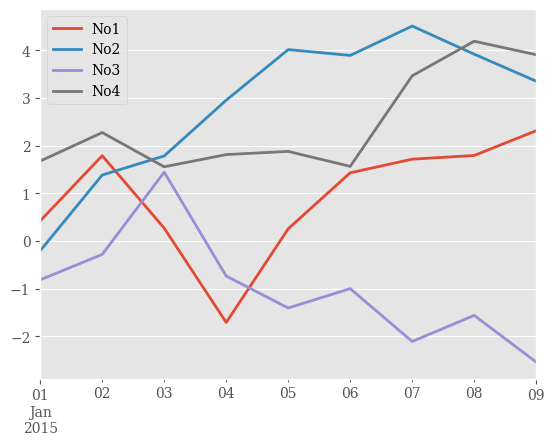

In [39]:
%matplotlib inline
df.cumsum().plot(lw=2.0, grid=True)
# tag: dataframe_plot
# title: Line plot of a DataFrame object

### Series Class

In [40]:
type(df)

pandas.core.frame.DataFrame

In [41]:
df['No1']

2015-01-01    0.423495
2015-01-02    1.367746
2015-01-03   -1.520809
2015-01-04   -1.977869
2015-01-05    1.964831
2015-01-06    1.174812
2015-01-07    0.285850
2015-01-08    0.077286
2015-01-09    0.520565
Freq: D, Name: No1, dtype: float64

In [42]:
type(df['No1'])

pandas.core.series.Series

Text(0, 0.5, 'value')

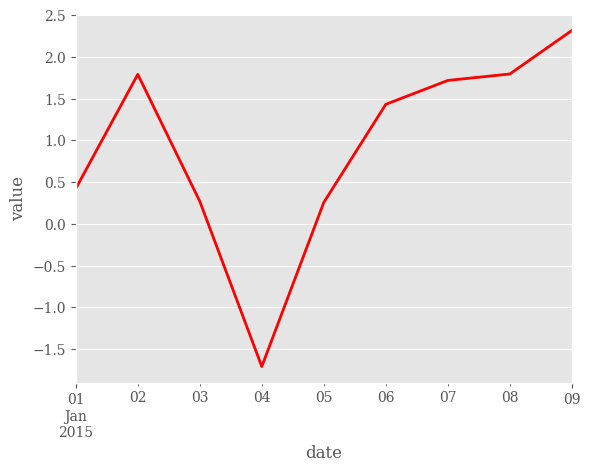

In [43]:
import matplotlib.pyplot as plt
df['No1'].cumsum().plot(style='r', lw=2., grid=True)
plt.xlabel('date')
plt.ylabel('value')
# tag: time_series
# title: Line plot of a Series object

### GroupBy Operations

In [44]:
df['Quarter'] = ['Q1', 'Q1', 'Q1', 'Q2', 'Q2', 'Q2', 'Q3', 'Q3', 'Q3']
df

,No1,No2,No3,No4,Quarter
2015-01-01,0.423495,-0.202296,-0.813504,1.678197,Q1
2015-01-02,1.367746,1.587229,0.533816,0.597964,Q1
2015-01-03,-1.520809,0.400532,1.725188,-0.718432,Q1
2015-01-04,-1.977869,1.169865,-2.179774,0.256576,Q2
2015-01-05,1.964831,1.061122,-0.669239,0.066376,Q2
2015-01-06,1.174812,-0.122311,0.405334,-0.313865,Q2
2015-01-07,0.285850,0.615770,-1.108309,1.900194,Q3
2015-01-08,0.077286,-0.589497,0.547255,0.725146,Q3
2015-01-09,0.520565,-0.567541,-0.979461,-0.283658,Q3


In [45]:
groups = df.groupby('Quarter')

In [46]:
groups

In [47]:
groups.mean()

,No1,No2,No3,No4
Quarter,,,,
Q1,0.090144,0.595155,0.481833,0.519243
Q2,0.387258,0.702892,-0.814560,0.003029
Q3,0.294567,-0.180423,-0.513505,0.780561


In [48]:
groups.max()

,No1,No2,No3,No4
Quarter,,,,
Q1,1.367746,1.587229,1.725188,1.678197
Q2,1.964831,1.169865,0.405334,0.256576
Q3,0.520565,0.615770,0.547255,1.900194


In [49]:
groups.size()

Quarter
Q1    3
Q2    3
Q3    3
dtype: int64

In [50]:
df['Odd_Even'] = ['Odd', 'Even', 'Odd', 'Even', 'Odd', 'Even',
                  'Odd', 'Even', 'Odd']

In [51]:
groups = df.groupby(['Quarter', 'Odd_Even'])

In [52]:
groups.size()

Quarter  Odd_Even
Q1       Even        1
         Odd         2
Q2       Even        2
         Odd         1
Q3       Even        1
         Odd         2
dtype: int64

In [53]:
groups.mean()

No1       No2       No3       No4
Quarter Odd_Even                                        
Q1      Even      1.367746  1.587229  0.533816  0.597964
        Odd      -0.548657  0.099118  0.455842  0.479882
Q2      Even     -0.401528  0.523777 -0.887220 -0.028645
        Odd       1.964831  1.061122 -0.669239  0.066376
Q3      Even      0.077286 -0.589497  0.547255  0.725146
        Odd       0.403208  0.024114 -1.043885  0.808268

## Financial Data

In [54]:
# data from Thomson Reuters Eikon API
raw = pd.read_csv('tr_eikon_eod_data.csv',
                 index_col=0, parse_dates=True)
raw.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1972 entries, 2010-01-04 to 2017-10-31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL.O  1972 non-null   float64
 1   MSFT.O  1972 non-null   float64
 2   INTC.O  1972 non-null   float64
 3   AMZN.O  1972 non-null   float64
 4   GS.N    1972 non-null   float64
 5   SPY     1972 non-null   float64
 6   .SPX    1972 non-null   float64
 7   .VIX    1972 non-null   float64
 8   EUR=    1972 non-null   float64
 9   XAU=    1972 non-null   float64
 10  GDX     1972 non-null   float64
 11  GLD     1972 non-null   float64
dtypes: float64(12)
memory usage: 200.3 KB


In [55]:
data = pd.DataFrame(raw['.SPX'])
data.columns = ['Close']

In [56]:
data.tail()

,Close
Date,
2017-10-25,2557.15
2017-10-26,2560.40
2017-10-27,2581.07
2017-10-30,2572.83
2017-10-31,2575.26


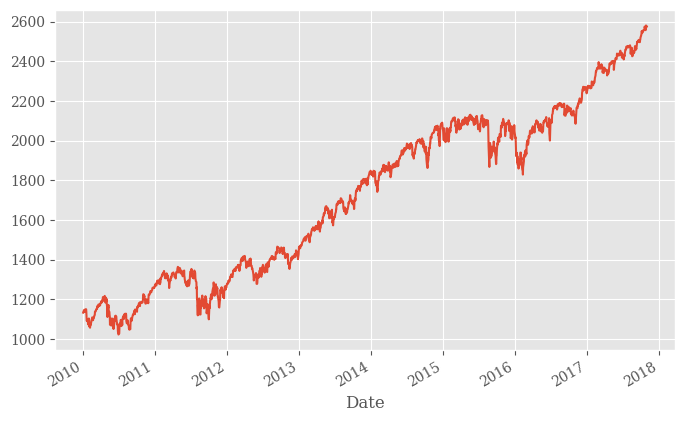

In [57]:
data['Close'].plot(figsize=(8, 5), grid=True);
# tag: dax
# title: Historical DAX index levels

In [58]:
%time data['Return'] = np.log(data['Close'] / data['Close'].shift(1))

CPU times: total: 0 ns
Wall time: 1.01 ms


In [59]:
data[['Close', 'Return', 'Return']].tail()

,Close,Return,Return
Date,,,
2017-10-25,2557.15,-0.004674,-0.004674
2017-10-26,2560.40,0.001270,0.001270
2017-10-27,2581.07,0.008041,0.008041
2017-10-30,2572.83,-0.003198,-0.003198
2017-10-31,2575.26,0.000944,0.000944


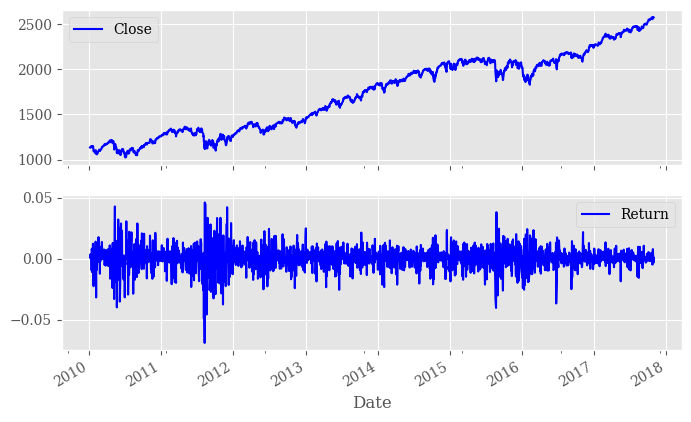

In [60]:
data[['Close', 'Return']].plot(subplots=True, style='b',
                              figsize=(8, 5), grid=True);
# tag: dax_returns
# title: The S&P 500 index and daily log returns

In [61]:
data['42d'] = data['Close'].rolling(window=42).mean()
data['252d'] = data['Close'].rolling(window=252).mean()

In [62]:
data[['Close', '42d', '252d']].tail()

,Close,42d,252d
Date,,,
2017-10-25,2557.15,2515.261429,2372.400873
2017-10-26,2560.40,2518.027143,2374.071389
2017-10-27,2581.07,2521.235952,2375.849286
2017-10-30,2572.83,2523.979762,2377.620794
2017-10-31,2575.26,2526.446667,2379.402976


<Axes: xlabel='Date'>

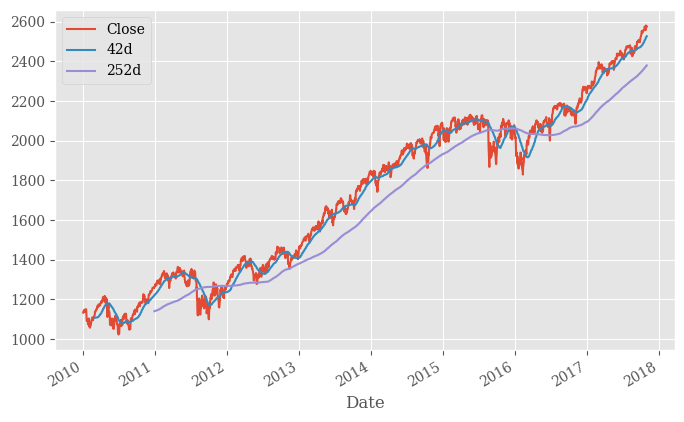

In [63]:
data[['Close', '42d', '252d']].plot(figsize=(8, 5), grid=True)
# tag: dax_trends
# title: The S&P index and moving averages

In [64]:
import math
data['Mov_Vol'] = data['Return'].rolling(window=252).std() * math.sqrt(252)
  # moving annual volatility

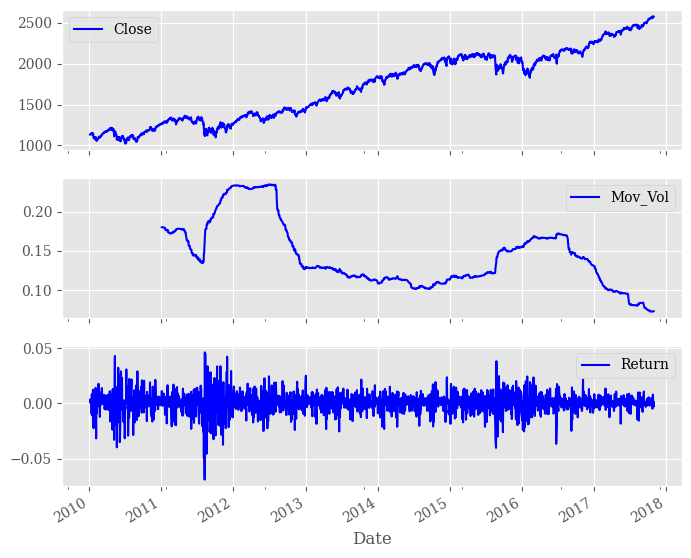

In [65]:
data[['Close', 'Mov_Vol', 'Return']].plot(subplots=True, style='b',
                                         figsize=(8, 7), grid=True);
# tag: dax_mov_std
# title: The S&P index and moving, annualized volatility

## Regression Analysis

In [66]:
import pandas as pd

In [67]:
# data from Thomson Reuters Eikon API
raw = pd.read_csv('tr_eikon_eod_data.csv',
                 index_col=0, parse_dates=True)
spx = pd.DataFrame(raw['.SPX'])

In [68]:
np.round(spx.tail())

,.SPX
Date,
2017-10-25,2557.0
2017-10-26,2560.0
2017-10-27,2581.0
2017-10-30,2573.0
2017-10-31,2575.0


In [69]:
vix = pd.DataFrame(raw['.VIX'])
vix.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1972 entries, 2010-01-04 to 2017-10-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   .VIX    1972 non-null   float64
dtypes: float64(1)
memory usage: 30.8 KB


In [70]:
data = spx.join(vix)

In [71]:
data.tail()

,.SPX,.VIX
Date,,
2017-10-25,2557.15,11.23
2017-10-26,2560.40,11.30
2017-10-27,2581.07,9.80
2017-10-30,2572.83,10.50
2017-10-31,2575.26,10.18


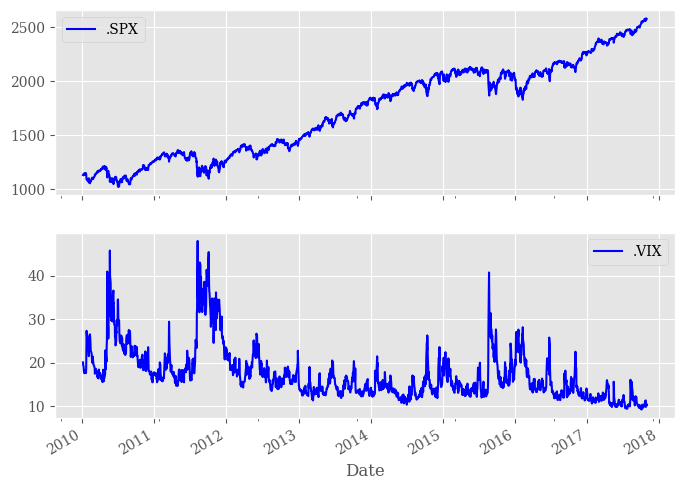

In [72]:
data.plot(subplots=True, grid=True, style='b', figsize=(8, 6));
# tag: spx_vix
# title: The S&P 500 Index and the VIX volatility index

In [73]:
rets = np.log(data / data.shift(1)) 
rets.head()

,.SPX,.VIX
Date,,
2010-01-04,NaN,NaN
2010-01-05,0.003111,-0.035038
2010-01-06,0.000545,-0.009868
2010-01-07,0.003993,-0.005233
2010-01-08,0.002878,-0.050024


In [74]:
rets.dropna(inplace=True)

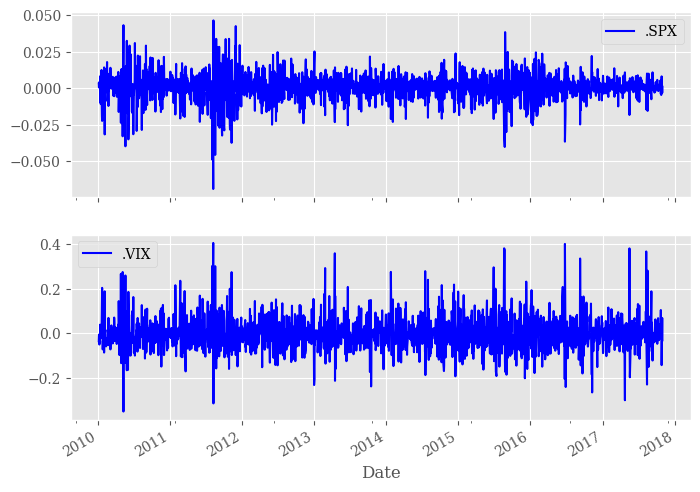

In [75]:
rets.plot(subplots=True, grid=True, style='b', figsize=(8, 6));
# tag: es50_vs_rets
# title: Log returns of S&P500 and VIX

In [76]:
import numpy as np

In [77]:
xdat = rets['.SPX'].values
ydat = rets['.VIX'].values
reg = np.polyfit(x=xdat, y=ydat, deg=1)
reg

array([-6.45336250e+00,  2.34474296e-03])

Text(0, 0.5, 'VIX returns')

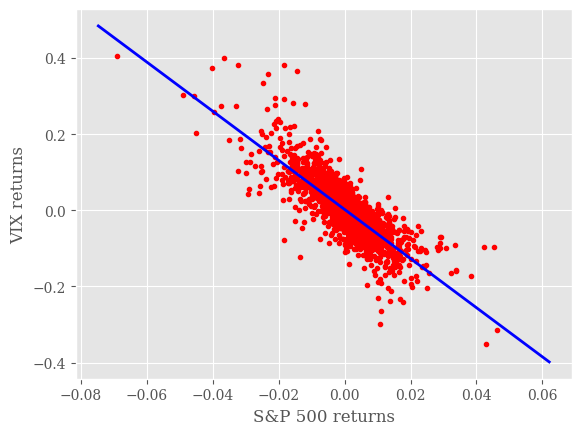

In [78]:
plt.plot(xdat, ydat, 'r.')
ax = plt.axis()  # grab axis values
x = np.linspace(ax[0], ax[1] + 0.01)
plt.plot(x, np.polyval(reg, x), 'b', lw=2)
plt.grid(True)
plt.axis('tight')
plt.xlabel('S&P 500 returns')
plt.ylabel('VIX returns')
# tag: scatter_rets
# title: Scatter plot of log returns and regression line

In [79]:
rets.corr()

,.SPX,.VIX
.SPX,1.000000,-0.808372
.VIX,-0.808372,1.000000


<Axes: xlabel='Date'>

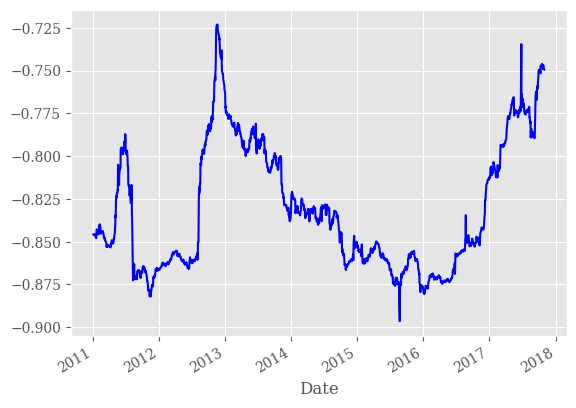

In [80]:
rets['.SPX'].rolling(window=252).corr(rets['.VIX']).plot(grid=True, style='b')
# tag: roll_corr
# title: Rolling correlation between S&P 500 and VIX

## High Frequency Data

In [81]:
import numpy as np
import pandas as pd
import datetime as dt
%matplotlib inline

In [82]:
# data from FXCM Forex Capital Markets Ltd.
eur_usd = pd.read_csv('fxcm_eur_usd_tick_data.csv',
                     index_col=0, parse_dates=True)

In [83]:
eur_usd.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17352 entries, 2017-11-10 12:00:00.007000 to 2017-11-10 14:00:00.131000
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Bid     17352 non-null  float64
 1   Ask     17352 non-null  float64
dtypes: float64(2)
memory usage: 406.7 KB


In [84]:
eur_usd['Mid'] = eur_usd.mean(axis=1)

In [85]:
eur_usd.head()

,Bid,Ask,Mid
2017-11-10 12:00:00.007,1.16395,1.16394,1.163945
2017-11-10 12:00:00.053,1.16394,1.16394,1.163940
2017-11-10 12:00:00.740,1.16394,1.16393,1.163935
2017-11-10 12:00:00.746,1.16394,1.16391,1.163925
2017-11-10 12:00:00.756,1.16394,1.16392,1.163930


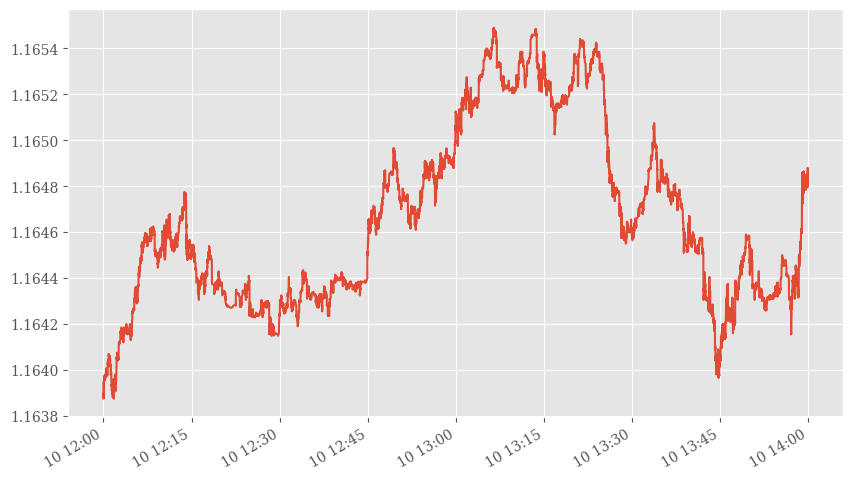

In [86]:
eur_usd['Mid'].plot(figsize=(10, 6));
# tag: eur_uusd
# title: EUR/USD tick data for two hours

In [87]:
eur_usd_resam = eur_usd.resample(rule='1min', label='left').last()
eur_usd_resam.head()

,Bid,Ask,Mid
2017-11-10 12:00:00,1.16406,1.16407,1.164065
2017-11-10 12:01:00,1.16396,1.16397,1.163965
2017-11-10 12:02:00,1.16416,1.16418,1.164170
2017-11-10 12:03:00,1.16417,1.16417,1.164170
2017-11-10 12:04:00,1.16425,1.16427,1.164260


<Axes: >

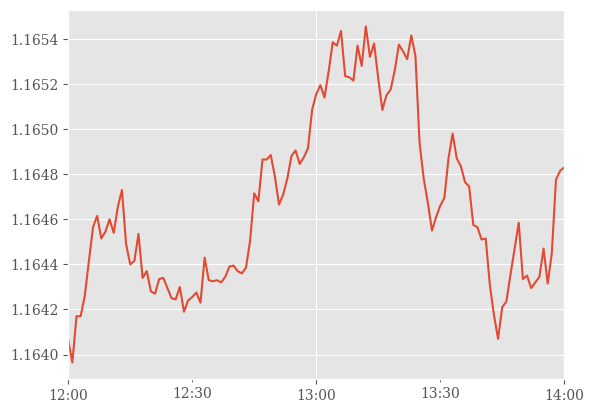

In [88]:
eur_usd_resam['Mid'].plot(grid=True)
# tag: eur_usd_resam
# title: Resampled EUR/USD exchange rate tick data

## Conclusions

## Further Reading

<img src="http://hilpisch.com/tpq_logo.png" alt="The Python Quants" width="35%" align="right" border="0"><br>

<a href="http://tpq.io" target="_blank">http://tpq.io</a> | <a href="http://twitter.com/dyjh" target="_blank">@dyjh</a> | <a href="mailto:training@tpq.io">training@tpq.io</a>

**Quant Platform** |
<a href="http://quant-platform.com">http://quant-platform.com</a>

**Python for Finance** |
<a href="http://python-for-finance.com" target="_blank">Python for Finance @ O'Reilly</a>

**Derivatives Analytics with Python** |
<a href="http://derivatives-analytics-with-python.com" target="_blank">Derivatives Analytics @ Wiley Finance</a>

**Listed Volatility and Variance Derivatives** |
<a href="http://lvvd.tpq.io" target="_blank">Listed VV Derivatives @ Wiley Finance</a>

**Python Training** |
<a href="http://training.tpq.io" target="_blank">Python for Finance University Certificate</a>